Data Cleaning

In [1]:
#importing our librabries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn

In [2]:
#Loading the dataset
project1 = pd.read_excel('Dataset for Data Analytics.xlsx')
project1.head(5)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
#Checking the dataset information
project1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [4]:
#Describing the dataset
project1.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [5]:
#Checking for duplicates
project1.duplicated().sum()

np.int64(0)

In [6]:
#Checking for missing values
project1.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [7]:
#percentage of missing value
project = round((project1['CouponCode'].isnull().sum() / len(project1['CouponCode']))* 100, 2)
project

np.float64(25.75)

In [8]:
#filling up the missing values
project1['CouponCode'] = project1['CouponCode'].fillna('NO COUPON CODE')
project1['CouponCode']

0               SAVE10
1               SAVE10
2             FREESHIP
3               SAVE10
4               SAVE10
             ...      
1195          FREESHIP
1196    NO COUPON CODE
1197          FREESHIP
1198          WINTER15
1199            SAVE10
Name: CouponCode, Length: 1200, dtype: object

([0, 1, 2, 3],
 [Text(0, 0, 'Quantity'),
  Text(1, 0, 'UnitPrice'),
  Text(2, 0, 'ItemsInCart'),
  Text(3, 0, 'TotalPrice')])

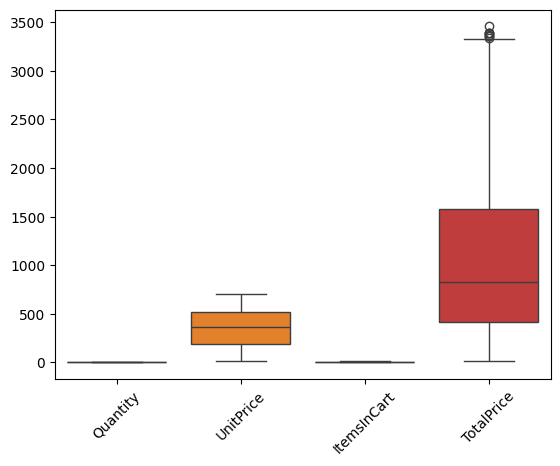

In [9]:
#Checking for outliers using a boxplot
sns.boxplot(data=project1)
plt.xticks(rotation=45)

In [10]:
#applying winsorization for outliers
from scipy.stats.mstats import winsorize
project1['TotalPrice'] = winsorize(project1['TotalPrice'], limits=[0.01, 0.01])

In [11]:
#Describing the dataset
project1.describe()

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.338292
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,36.650000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3277.750000
std,NaN,1.407557,197.177146,2.281983,817.518825


In [12]:
#Converting the data column that is an object to a datetime column
project1['Date'] = pd.to_datetime(project1['Date'])
project1['Date']

0      2023-01-04
1      2024-08-23
2      2024-02-27
3      2023-10-15
4      2025-05-08
          ...    
1195   2024-06-20
1196   2024-03-04
1197   2023-07-13
1198   2024-08-22
1199   2023-06-11
Name: Date, Length: 1200, dtype: datetime64[ns]

In [13]:
#Saving the cleaned dataset
project1.to_excel('Project1_cleaned_data.xlsx')